# Trabajo Practico 3 - EDA aplicado

## Objetivo
Realizar un analisis exploratorio de datos mas completo sobre el dataset de partidos de tenis ATP.


## Dataset elegido: atp_tennis.csv

El analisis se limita a los partidos disputados durante el ano 2000. Los valores -1 de las variables numericas se interpretan como datos faltantes y se reemplazan por `NaN`.

## 1. Importacion de librerias y carga del dataset

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')

ruta = 'datasets/atp_tennis.csv'
df = pd.read_csv(ruta)
df['Date'] = pd.to_datetime(df['Date'])
#df = df[df['Date'].dt.year == 2015].copy()

cols_centinela = ['Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Rank_1', 'Rank_2']
df[cols_centinela] = df[cols_centinela].replace(-1, np.nan)

print('Cantidad de registros de la muestra:', len(df))
display(df.head())

Cantidad de registros de la muestra: 68591


,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105.0,58.0,NaN,NaN,NaN,NaN,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218.0,11.0,NaN,NaN,NaN,NaN,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56.0,5.0,NaN,NaN,NaN,NaN,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63.0,77.0,NaN,NaN,NaN,NaN,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155.0,15.0,NaN,NaN,NaN,NaN,4-6 4-6


## 2. Columnas, tipos y vista general

Primero se revisan las dimensiones, los nombres de las columnas, los tipos de datos y una muestra de los registros.

In [32]:
print('Dimensiones del dataset:', df.shape)
print('\nNombres de las columnas:')
print(df.columns.tolist())
print('\nTipos de datos y valores no nulos:')
df.info()
display(df.head())

Dimensiones del dataset: (68591, 17)

Nombres de las columnas:
['Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Player_1', 'Player_2', 'Winner', 'Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Score']

Tipos de datos y valores no nulos:
<class 'pandas.DataFrame'>
RangeIndex: 68591 entries, 0 to 68590
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tournament  68591 non-null  str           
 1   Date        68591 non-null  datetime64[us]
 2   Series      68591 non-null  str           
 3   Court       68591 non-null  str           
 4   Surface     68591 non-null  str           
 5   Round       68591 non-null  str           
 6   Best of     68591 non-null  int64         
 7   Player_1    68591 non-null  str           
 8   Player_2    68591 non-null  str           
 9   Winner      68591 non-null  str           
 10  Rank_1      68577 non-null  float64       
 11  Ra

,Tournament,Date,Series,Court,Surface,Round,Best of,Player_1,Player_2,Winner,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Score
0,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Arthurs W.,Gambill J.M.,Gambill J.M.,105.0,58.0,NaN,NaN,NaN,NaN,6-3 6-7 4-6
1,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Balcells J.,Henman T.,Henman T.,218.0,11.0,NaN,NaN,NaN,NaN,4-6 6-7
2,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Clement A.,Enqvist T.,Enqvist T.,56.0,5.0,NaN,NaN,NaN,NaN,3-6 3-6
3,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Dosedel S.,Ljubicic I.,Dosedel S.,63.0,77.0,NaN,NaN,NaN,NaN,6-4 6-2
4,Australian Hardcourt Championships,2000-01-03,International,Outdoor,Hard,1st Round,3,Draper S.,Norman M.,Norman M.,155.0,15.0,NaN,NaN,NaN,NaN,4-6 4-6


In [33]:
cuantitativas = ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Best of']
categoricas = ['Tournament', 'Series', 'Court', 'Surface', 'Round', 'Player_1', 'Player_2', 'Winner']
temporales = ['Date']

print('CLASIFICACION TEORICA DE VARIABLES')
print('Cuantitativas:', cuantitativas)
print('Categoricas:', categoricas)
print('Temporales:', temporales)

CLASIFICACION TEORICA DE VARIABLES
Cuantitativas: ['Rank_1', 'Rank_2', 'Pts_1', 'Pts_2', 'Odd_1', 'Odd_2', 'Best of']
Categoricas: ['Tournament', 'Series', 'Court', 'Surface', 'Round', 'Player_1', 'Player_2', 'Winner']
Temporales: ['Date']


## 3. Variables categoricas: frecuencias y proporciones

In [34]:
print('Cantidad de categorias y categoria mas frecuente')
resumen_categoricas = pd.DataFrame({
    'cardinalidad': df[categoricas].nunique(),
    'moda': [df[col].mode().iloc[0] if not df[col].mode().empty else np.nan for col in categoricas],
    'frecuencia_moda': [df[col].value_counts().iloc[0] if not df[col].value_counts().empty else 0 for col in categoricas]
})
display(resumen_categoricas)

print('Frecuencia de superficie:')
display(df['Surface'].value_counts().to_frame('partidos'))
print('Frecuencia de resultado:')
display(df['Winner'].value_counts().to_frame('victorias'))

Cantidad de categorias y categoria mas frecuente


,cardinalidad,moda,frecuencia_moda
Tournament,268,French Open,3289
Series,8,ATP250,18268
Court,2,Outdoor,56570
Surface,4,Hard,37074
Round,8,1st Round,31379
Player_1,1558,Federer R.,668
Player_2,1537,Federer R.,725
Winner,1201,Federer R.,1151


Frecuencia de superficie:


,partidos
Surface,
Hard,37074
Clay,22152
Grass,7733
Carpet,1632


Frecuencia de resultado:


,victorias
Winner,
Federer R.,1151
Djokovic N.,1072
Nadal R.,1007
Ferrer D.,677
Murray A.,670
...,...
Midon L.,1
Bueno G.,1
Feldbausch K.,1


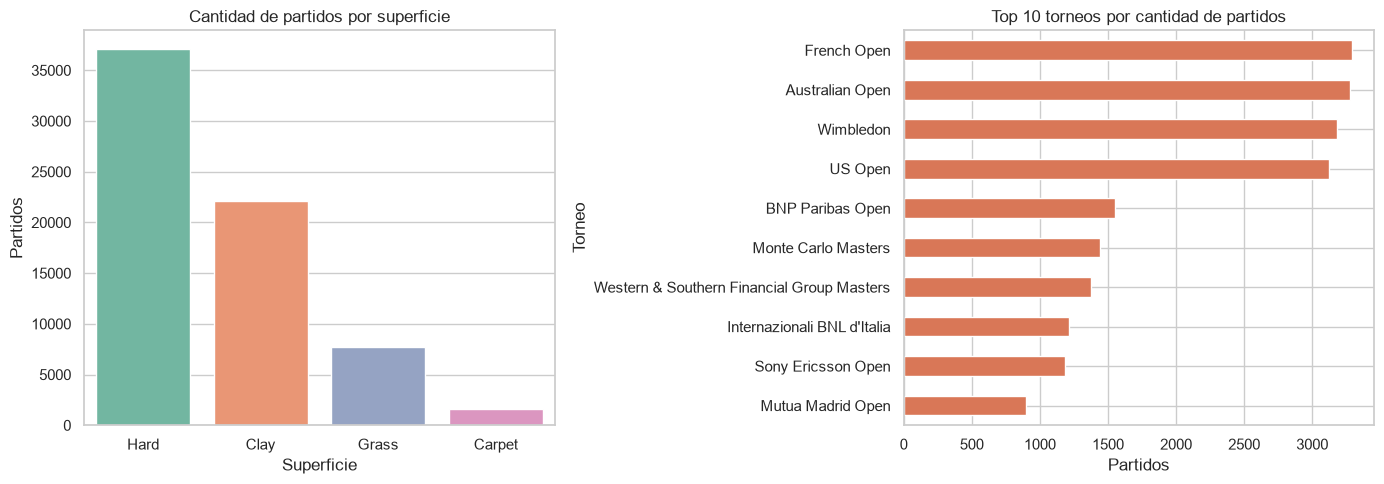

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='Surface', hue='Surface', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('Cantidad de partidos por superficie')
axes[0].set_xlabel('Superficie')
axes[0].set_ylabel('Partidos')

top_tournaments = df['Tournament'].value_counts().head(10).sort_values()
top_tournaments.plot(kind='barh', ax=axes[1], color='#d97757')
axes[1].set_title('Top 10 torneos por cantidad de partidos')
axes[1].set_xlabel('Partidos')
axes[1].set_ylabel('Torneo')
plt.tight_layout()
plt.show()

## 4. Variables numericas: estadistica descriptiva

Se observan cantidad de datos, media, desvio estandar, percentiles, minimo y maximo.

,count,mean,std,min,25%,50%,75%,max
Rank_1,68577.0,75.837467,100.220581,1.0,25.0,54.000,92.00,3390.0
Rank_2,68579.0,75.418379,100.636030,1.0,24.0,54.000,92.00,4915.0
Pts_1,52939.0,1483.586014,1835.591154,1.0,589.0,895.000,1535.00,16950.0
Pts_2,52938.0,1492.804224,1857.768887,1.0,591.0,895.000,1535.00,16950.0
Odd_1,64809.0,2.622275,2.620636,0.0,1.4,1.830,2.75,67.0
Odd_2,64811.0,2.613958,2.579847,0.0,1.4,1.833,2.75,51.0
Best of,68591.0,3.377455,0.782590,3.0,3.0,3.000,3.00,5.0


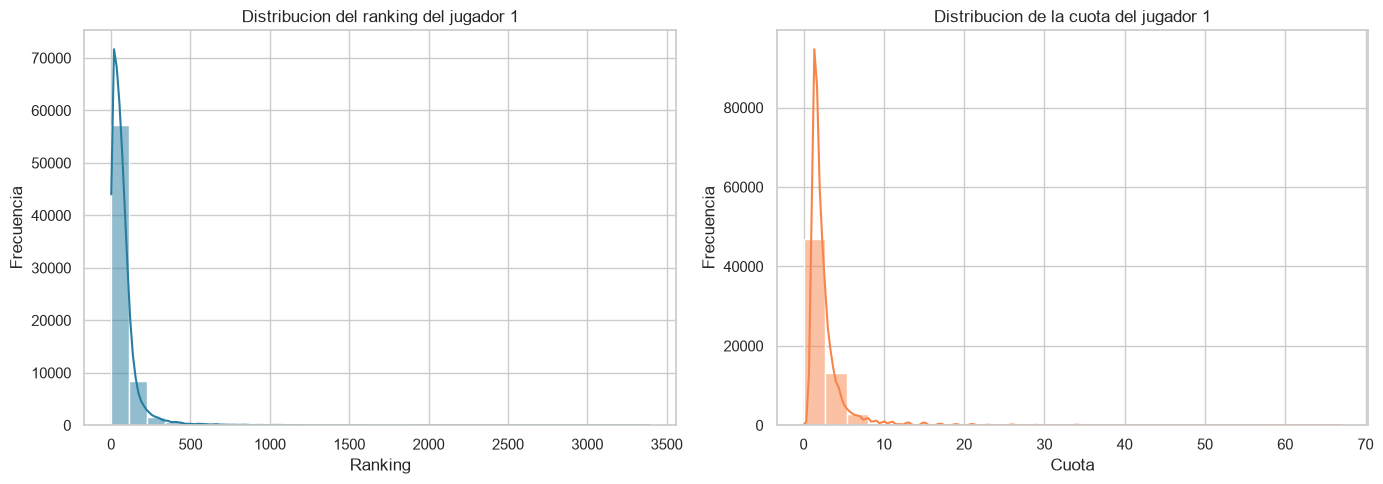

In [36]:
display(df[cuantitativas].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='Rank_1', bins=30, kde=True, color='#277da1', ax=axes[0])
axes[0].set_title('Distribucion del ranking del jugador 1')
axes[0].set_xlabel('Ranking')
axes[0].set_ylabel('Frecuencia')

sns.histplot(data=df, x='Odd_1', bins=25, kde=True, color='#f9844a', ax=axes[1])
axes[1].set_title('Distribucion de la cuota del jugador 1')
axes[1].set_xlabel('Cuota')
axes[1].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

## 5. Relaciones entre variables

Se analiza la asociacion entre variables numericas y se compara el ranking del jugador 1 segun la superficie.

Matriz de correlacion entre variables numericas:


,Rank_1,Rank_2,Pts_1,Pts_2,Odd_1,Odd_2,Best of
Rank_1,1.000000,0.064625,-0.364039,-0.088544,0.245411,-0.223458,-0.032170
Rank_2,0.064625,1.000000,-0.087635,-0.353325,-0.218923,0.233943,-0.034627
Pts_1,-0.364039,-0.087635,1.000000,0.154207,-0.188359,0.586996,0.084377
Pts_2,-0.088544,-0.353325,0.154207,1.000000,0.583600,-0.194547,0.082717
Odd_1,0.245411,-0.218923,-0.188359,0.583600,1.000000,-0.285859,0.146301
Odd_2,-0.223458,0.233943,0.586996,-0.194547,-0.285859,1.000000,0.141205
Best of,-0.032170,-0.034627,0.084377,0.082717,0.146301,0.141205,1.000000


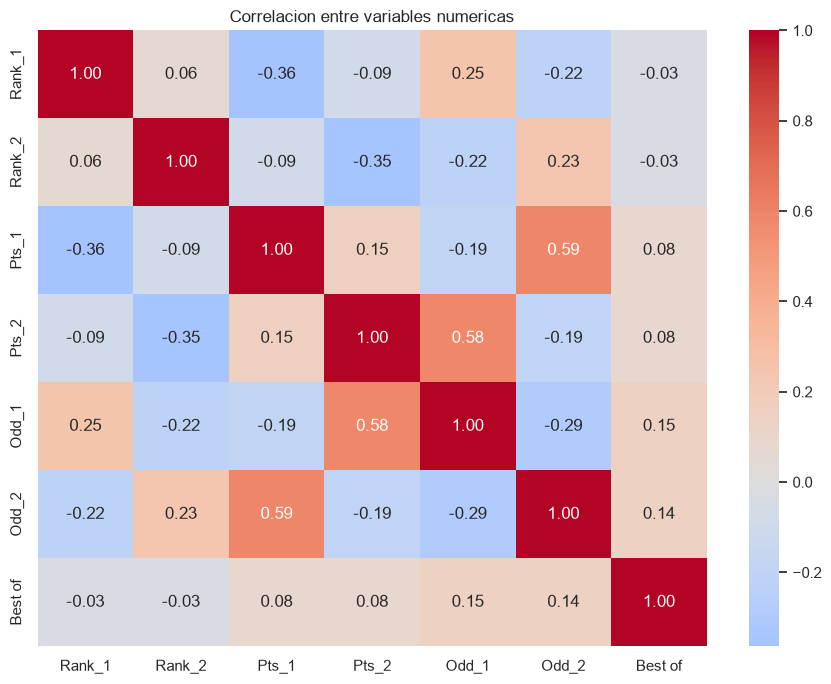

In [37]:
print('Matriz de correlacion entre variables numericas:')
correlaciones = df[cuantitativas].corr(numeric_only=True)
display(correlaciones)

plt.figure(figsize=(9, 7))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlacion entre variables numericas')
plt.tight_layout()
plt.show()

Tabla de contingencia: superficie vs cancha


Court,Indoor,Outdoor,All
Surface,,,
Carpet,1632,0,1632
Clay,394,21758,22152
Grass,0,7733,7733
Hard,9995,27079,37074
All,12021,56570,68591


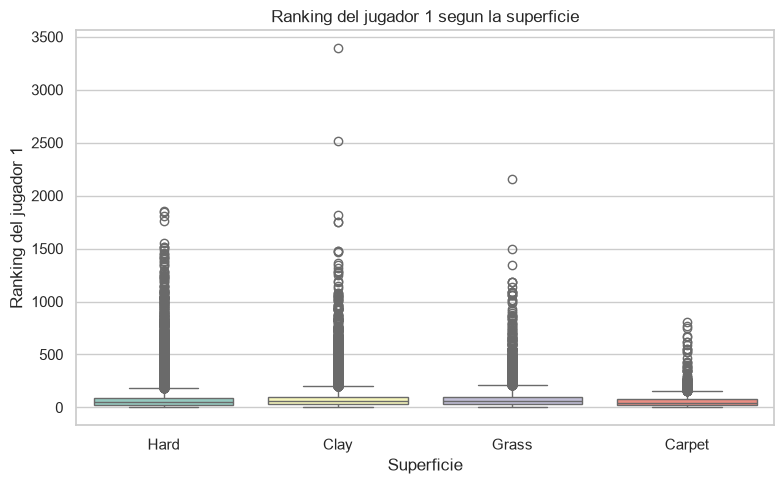

In [38]:
print('Tabla de contingencia: superficie vs cancha')
tabla_contingencia = pd.crosstab(df['Surface'], df['Court'], margins=True)
display(tabla_contingencia)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Surface', y='Rank_1', hue='Surface', legend=False, palette='Set3')
plt.title('Ranking del jugador 1 segun la superficie')
plt.xlabel('Superficie')
plt.ylabel('Ranking del jugador 1')
plt.tight_layout()
plt.show()

## 6. Datos faltantes

Los valores -1 del archivo fueron convertidos a `NaN`. Ahora se calcula el total y el porcentaje de faltantes por columna, y se revisa si se concentran en alguna superficie.

In [39]:
faltantes = df.isna().sum().to_frame('faltantes')
faltantes['porcentaje'] = (faltantes['faltantes'] / len(df) * 100).round(2)
faltantes = faltantes.sort_values('faltantes', ascending=False)
display(faltantes[faltantes['faltantes'] > 0])

,faltantes,porcentaje
Pts_2,15653,22.82
Pts_1,15652,22.82
Odd_1,3782,5.51
Odd_2,3780,5.51
Rank_1,14,0.02
Rank_2,12,0.02


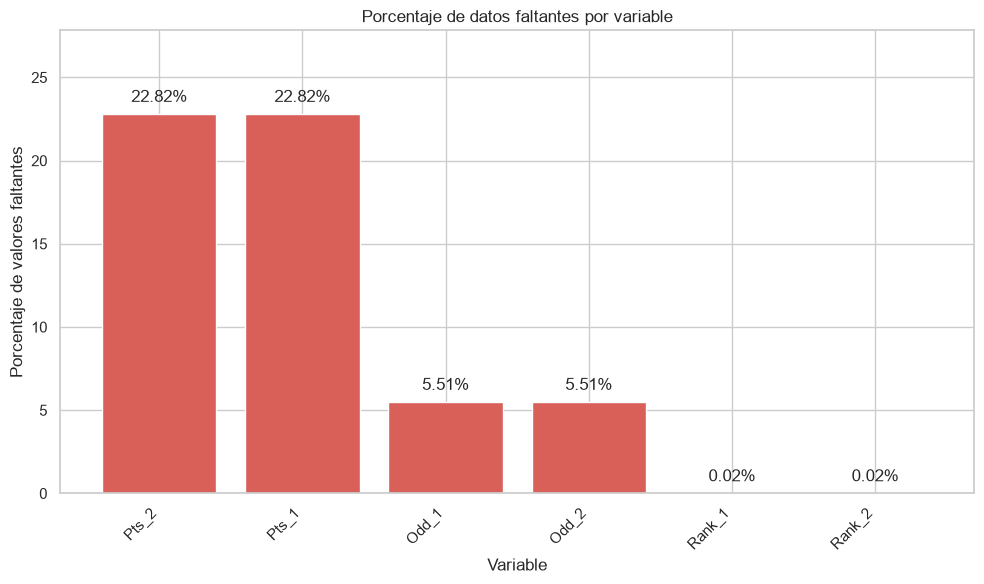

Porcentaje de faltantes por superficie:


,Pts_1,Pts_2,Odd_1,Odd_2,Rank_1,Rank_2
Surface,,,,,,
Carpet,52.39,52.39,10.60,10.60,0.00,0.00
Clay,24.60,24.60,5.63,5.62,0.01,0.02
Grass,22.66,22.66,4.80,4.80,0.03,0.03
Hard,20.49,20.49,5.37,5.37,0.02,0.01


In [40]:
faltantes_grafico = faltantes[faltantes['faltantes'] > 0].sort_values('porcentaje', ascending=False)

plt.figure(figsize=(10, 6))
barras = plt.bar(
    faltantes_grafico.index,
    faltantes_grafico['porcentaje'],
    color='#d95f59'
)

for barra, porcentaje in zip(barras, faltantes_grafico['porcentaje']):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f'{porcentaje:.2f}%',
        ha='center',
        va='bottom'
    )

plt.title('Porcentaje de datos faltantes por variable')
plt.xlabel('Variable')
plt.ylabel('Porcentaje de valores faltantes')
plt.ylim(0, faltantes_grafico['porcentaje'].max() + 5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

faltantes_por_superficie = df.groupby('Surface', observed=True)[cols_centinela].apply(lambda grupo: grupo.isna().mean() * 100).round(2)
print('Porcentaje de faltantes por superficie:')
display(faltantes_por_superficie)

Interpretacion inicial: los valores faltantes se encuentran principalmente en puntos, cuotas y rankings. Como fueron codificados originalmente con `-1`, no deben analizarse como valores numericos reales. La concentracion por superficie permite investigar si el faltante depende del contexto del partido.

## 7. Deteccion de valores atipicos


In [41]:
numericas_con_datos = df[cuantitativas].dropna(axis=1, how='all')
numericas_sin_faltantes = numericas_con_datos.loc[:, numericas_con_datos.nunique(dropna=True) > 1]
Q1 = numericas_sin_faltantes.quantile(0.25)
Q3 = numericas_sin_faltantes.quantile(0.75)
IQR = Q3 - Q1
columnas_con_variacion = IQR[IQR > 0].index
Q1 = Q1[columnas_con_variacion]
Q3 = Q3[columnas_con_variacion]
IQR = IQR[columnas_con_variacion]
limites_outliers = pd.DataFrame({
    'limite_inferior': Q1 - 1.5 * IQR,
    'limite_superior': Q3 + 1.5 * IQR
})
display(limites_outliers)

mascara_outliers = (numericas_sin_faltantes[columnas_con_variacion] < limites_outliers['limite_inferior']) | (numericas_sin_faltantes[columnas_con_variacion] > limites_outliers['limite_superior'])
resumen_outliers = mascara_outliers.sum().to_frame('cantidad')
resumen_outliers['porcentaje'] = (resumen_outliers['cantidad'] / len(df) * 100).round(2)
display(resumen_outliers.sort_values('cantidad', ascending=False))

,limite_inferior,limite_superior
Rank_1,-75.500,192.500
Rank_2,-78.000,194.000
Pts_1,-830.000,2954.000
Pts_2,-825.000,2951.000
Odd_1,-0.625,4.775
Odd_2,-0.625,4.775


,cantidad,porcentaje
Odd_2,5712,8.33
Pts_1,5685,8.29
Pts_2,5653,8.24
Odd_1,5641,8.22
Rank_1,4151,6.05
Rank_2,3941,5.75


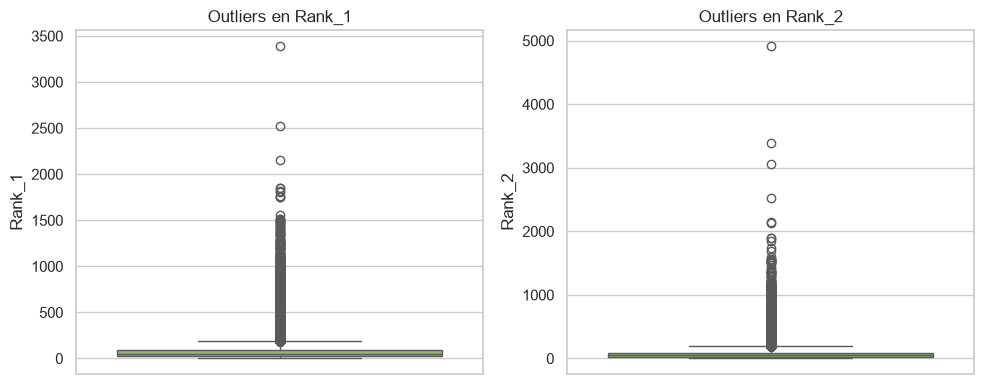

In [42]:
columnas_boxplot = ['Rank_1', 'Rank_2']
fig, axes = plt.subplots(1, len(columnas_boxplot), figsize=(10, 4))
for eje, columna in zip(axes, columnas_boxplot):
    sns.boxplot(y=df[columna], ax=eje, color='#90be6d')
    eje.set_title(f'Outliers en {columna}')
    eje.set_ylabel(columna)
plt.tight_layout()
plt.show()

In [43]:
print('Registros potencialmente atipicos en ranking del jugador 1:')
limite_rank_1 = limites_outliers.loc['Rank_1']
outliers_rank_1 = df[(df['Rank_1'] < limite_rank_1['limite_inferior']) | (df['Rank_1'] > limite_rank_1['limite_superior'])]
display(outliers_rank_1[['Tournament', 'Surface', 'Player_1', 'Player_2', 'Rank_1', 'Rank_2']].head(10))

Registros potencialmente atipicos en ranking del jugador 1:


,Tournament,Surface,Player_1,Player_2,Rank_1,Rank_2
1,Australian Hardcourt Championships,Hard,Balcells J.,Henman T.,218.0,11.0
12,Australian Hardcourt Championships,Hard,Petrovic D.,Huet S.,208.0,122.0
15,Australian Hardcourt Championships,Hard,Tebbutt M.,Lisnard J.,351.0,134.0
23,Australian Hardcourt Championships,Hard,Vinck C.,Stoltenberg J.,227.0,84.0
34,Gold Flake Open,Hard,Ishii Y.,Vanek J.,238.0,160.0
36,Gold Flake Open,Hard,Kilderry P.,Stanoytchev O.,342.0,111.0
38,Gold Flake Open,Hard,Kumar S.,Agenor R.,1198.0,94.0
40,Gold Flake Open,Hard,Ram A.,Pioline C.,414.0,14.0
43,Gold Flake Open,Hard,Spottl M.,Golmard J.,200.0,38.0
65,Qatar Open,Hard,Caratti C.,Heuberger I.,211.0,219.0


## 8. Enfrentamientos con mucha diferencia de ranking

En las variables de ranking, un numero menor representa una mejor posicion. Se comparan los partidos en los que un jugador pertenece al 25% con mejor ranking y el otro al 25% con peor ranking. Tambien se identifican los casos en los que gano el jugador peor rankeado.

Umbral de mejor ranking: hasta 25
Umbral de peor ranking: desde 92
Cantidad de enfrentamientos analizados: 6949
Comparacion de resultados:


,resultado,partidos,porcentaje
0,Gano el mejor ranking,5649,81.29
1,Gano el peor ranking,1300,18.71


Posibles batacazos: victorias del jugador con peor ranking


,Date,Tournament,Surface,jugador_mejor_ranking,ranking_mejor,jugador_peor_ranking,ranking_peor,Winner
63255,2024-07-17,Hall of Fame Championships,Grass,Mannarino A.,25.0,Opelka R.,1187.0,Opelka R.
64731,2025-03-08,BNP Paribas Open,Hard,Auger-Aliassime F.,18.0,Brooksby J.,937.0,Brooksby J.
11892,2004-03-14,Pacific Life Open,Hard,Srichaphan P.,11.0,Haas T.,882.0,Haas T.
11914,2004-03-15,Pacific Life Open,Hard,Costa A.,25.0,Haas T.,882.0,Haas T.
12600,2004-06-08,Stella Artois,Grass,Philippoussis M.,17.0,Flanagan I.,866.0,Flanagan I.
49528,2018-08-01,Citi Open,Hard,Edmund K.,18.0,Murray A.,832.0,Murray A.
4676,2001-07-16,Dutch Open,Clay,Grosjean S.,7.0,Chela J.I.,826.0,Chela J.I.
32992,2012-02-13,ABN AMRO World Tennis Tournament,Hard,Lopez F.,15.0,Mathieu P.H.,733.0,Mathieu P.H.
46547,2017-06-20,AEGON Championships,Grass,Raonic M.,6.0,Kokkinakis T.,698.0,Kokkinakis T.
19411,2006-10-11,Stockholm Open,Hard,Nadal R.,2.0,Johansson J.,690.0,Johansson J.


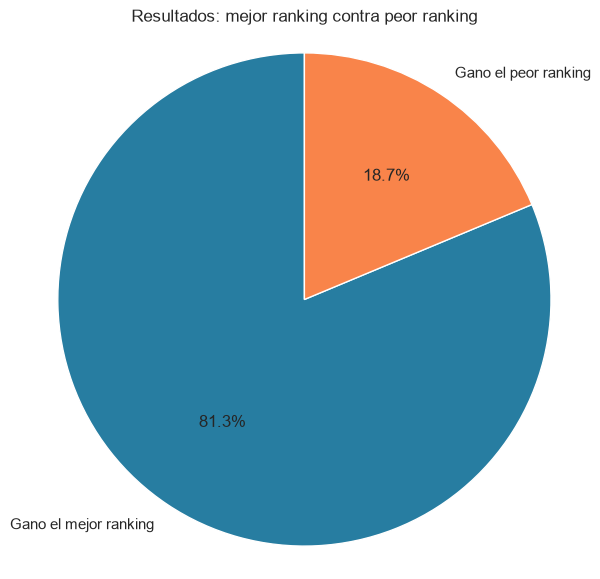

In [44]:
rank_1_mejor = df['Rank_1'].quantile(0.25)
rank_1_peor = df['Rank_1'].quantile(0.75)
rank_2_mejor = df['Rank_2'].quantile(0.25)
rank_2_peor = df['Rank_2'].quantile(0.75)

partidos_mejor_vs_peor = df[
    (((df['Rank_1'] <= rank_1_mejor) & (df['Rank_2'] >= rank_2_peor)) |
     ((df['Rank_2'] <= rank_2_mejor) & (df['Rank_1'] >= rank_1_peor)))
].copy()

partidos_mejor_vs_peor['jugador_mejor_ranking'] = np.where(
    partidos_mejor_vs_peor['Rank_1'] <= rank_1_mejor,
    partidos_mejor_vs_peor['Player_1'],
    partidos_mejor_vs_peor['Player_2']
)
partidos_mejor_vs_peor['ranking_mejor'] = np.where(
    partidos_mejor_vs_peor['Rank_1'] <= rank_1_mejor,
    partidos_mejor_vs_peor['Rank_1'],
    partidos_mejor_vs_peor['Rank_2']
)
partidos_mejor_vs_peor['jugador_peor_ranking'] = np.where(
    partidos_mejor_vs_peor['Rank_1'] >= rank_1_peor,
    partidos_mejor_vs_peor['Player_1'],
    partidos_mejor_vs_peor['Player_2']
)
partidos_mejor_vs_peor['ranking_peor'] = np.where(
    partidos_mejor_vs_peor['Rank_1'] >= rank_1_peor,
    partidos_mejor_vs_peor['Rank_1'],
    partidos_mejor_vs_peor['Rank_2']
)
partidos_mejor_vs_peor['gano_mejor_ranking'] = partidos_mejor_vs_peor['Winner'] == partidos_mejor_vs_peor['jugador_mejor_ranking']

print(f'Umbral de mejor ranking: hasta {rank_1_mejor:.0f}')
print(f'Umbral de peor ranking: desde {rank_1_peor:.0f}')
print(f'Cantidad de enfrentamientos analizados: {len(partidos_mejor_vs_peor)}')

resumen_mejor_vs_peor = pd.DataFrame({
    'resultado': ['Gano el mejor ranking', 'Gano el peor ranking'],
    'partidos': [
        partidos_mejor_vs_peor['gano_mejor_ranking'].sum(),
        (~partidos_mejor_vs_peor['gano_mejor_ranking']).sum()
    ]
})
resumen_mejor_vs_peor['porcentaje'] = (resumen_mejor_vs_peor['partidos'] / len(partidos_mejor_vs_peor) * 100).round(2)

print('Comparacion de resultados:')
display(resumen_mejor_vs_peor)

print('Posibles batacazos: victorias del jugador con peor ranking')
posibles_batacazos = partidos_mejor_vs_peor[
    ~partidos_mejor_vs_peor['gano_mejor_ranking']
][['Date', 'Tournament', 'Surface', 'jugador_mejor_ranking', 'ranking_mejor', 'jugador_peor_ranking', 'ranking_peor', 'Winner']]
display(posibles_batacazos.sort_values('ranking_peor', ascending=False).head(10))

plt.figure(figsize=(7, 7))
plt.pie(
    resumen_mejor_vs_peor['partidos'],
    labels=resumen_mejor_vs_peor['resultado'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#277da1', '#f9844a'],
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Resultados: mejor ranking contra peor ranking')
plt.axis('equal')
plt.show()

## 9. Ranking de jugadores con mas victorias por año

Se cuenta la cantidad de partidos ganados por cada jugador en cada año. 


Jugador con mas victorias en cada año:


,Year,Winner,victorias
0,2000,Safin M.,67
1,2001,Hewitt L.,70
2,2002,Hewitt L.,59
3,2003,Roddick A.,70
4,2004,Federer R.,69
5,2005,Federer R.,79
6,2006,Federer R.,89
7,2007,Nadal R.,68
8,2008,Nadal R.,72
9,2009,Djokovic N.,72


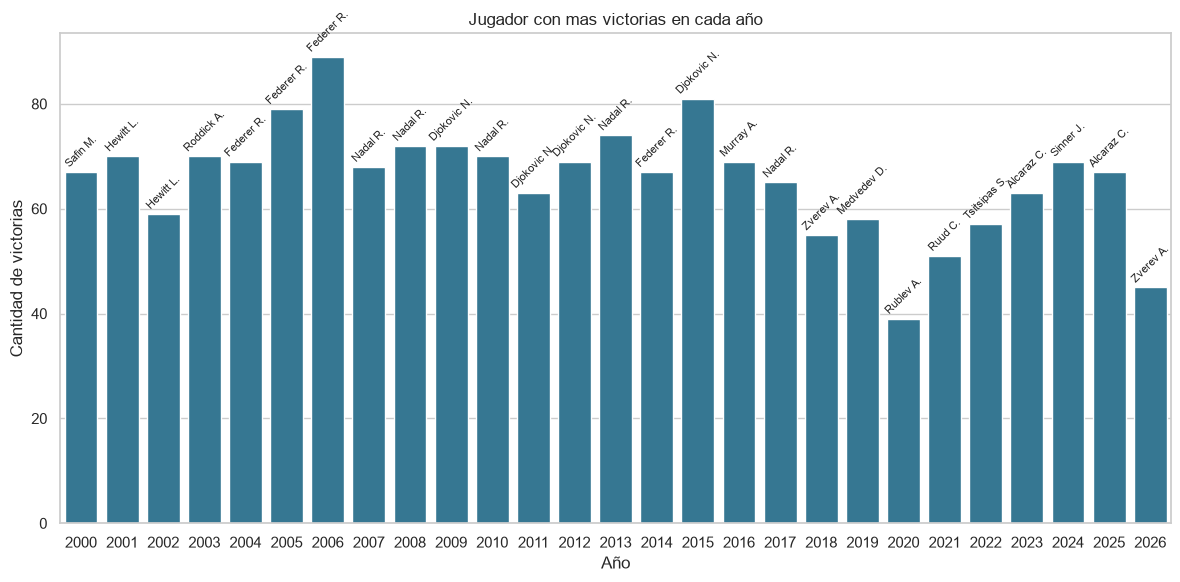

In [45]:
df['Year'] = df['Date'].dt.year

victorias_por_anio = (
    df.groupby(['Year', 'Winner'])
      .size()
      .reset_index(name='victorias')
      .sort_values(['Year', 'victorias', 'Winner'], ascending=[True, False, True])
)

lideres_por_anio = victorias_por_anio.groupby('Year', as_index=False).first()

print('Jugador con mas victorias en cada año:')
display(lideres_por_anio[['Year', 'Winner', 'victorias']])

plt.figure(figsize=(12, 6))
sns.barplot(data=lideres_por_anio, x='Year', y='victorias', color='#277da1')

for posicion, fila in enumerate(lideres_por_anio.itertuples()):
    plt.text(posicion, fila.victorias + 0.5, fila.Winner, ha='center', va='bottom', rotation=45, fontsize=8)

plt.title('Jugador con mas victorias en cada año')
plt.xlabel('Año')
plt.ylabel('Cantidad de victorias')
plt.tight_layout()
plt.show()